In [29]:
import numpy as np
import matplotlib.pyplot as plt
import cv2
from scipy.ndimage.morphology import binary_erosion, binary_dilation, binary_closing, binary_opening
from skimage.morphology import opening, closing, dilation, erosion
from skimage.io import imread
from skimage.util import invert
from math import ceil
from numpy import pad


C:\Users\user\AppData\Local\Temp\ipykernel_24480\3155533392.py:4: DeprecationWarning: Please import `binary_erosion` from the `scipy.ndimage` namespace; the `scipy.ndimage.morphology` namespace is deprecated and will be removed in SciPy 2.0.0.
  from scipy.ndimage.morphology import binary_erosion, binary_dilation, binary_closing, binary_opening
C:\Users\user\AppData\Local\Temp\ipykernel_24480\3155533392.py:4: DeprecationWarning: Please import `binary_dilation` from the `scipy.ndimage` namespace; the `scipy.ndimage.morphology` namespace is deprecated and will be removed in SciPy 2.0.0.
  from scipy.ndimage.morphology import binary_erosion, binary_dilation, binary_closing, binary_opening
C:\Users\user\AppData\Local\Temp\ipykernel_24480\3155533392.py:4: DeprecationWarning: Please import `binary_closing` from the `scipy.ndimage` namespace; the `scipy.ndimage.morphology` namespace is deprecated and will be removed in SciPy 2.0.0.
  from scipy.ndimage.morphology import binary_erosion, binary

# Вычисление и визуализация морфологического спектра

Разработать программу вычисления и визуализации морфологического спектра для бинарных и полутоновых изображений для различных структурирующих элементов (структурирующий элемент задается в виде аргумента).

Содержание отчета:
- Исходные изображения
- Код программы
- Результат работы программы

In [30]:
def show_images(images, columns=1, figsize=(5, 5)):
    
    if isinstance(images, np.ndarray):
        images = [images]
    rows = (len(images) + columns - 1) // columns
    fig, axes = plt.subplots(rows, columns, figsize=figsize)
    axes = np.array(axes).flatten()
    for i, img in enumerate(images):
        axes[i].imshow(img, cmap='gray', interpolation='none')
        axes[i].axis('off')
    for i in range(len(images), len(axes)):
        axes[i].axis('off')
    plt.tight_layout()
    plt.show()

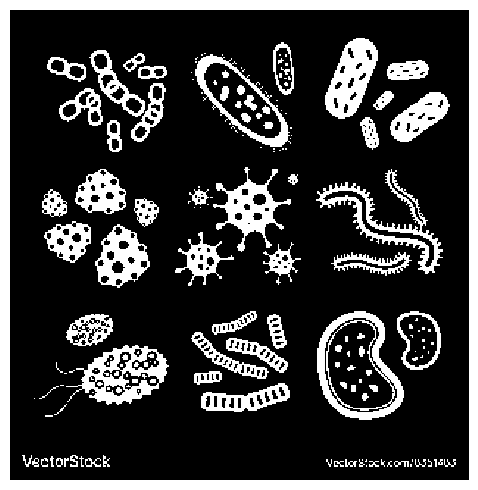

In [31]:
image_path = 'bakteries.png'
original_image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
binary_image = original_image > 127 

show_images(binary_image)

In [32]:
struct_el = np.ones((3, 3))

In [33]:
def compute_binary_spectrum(binary_img, struct_elem, max_steps=50):
    x_results = []
    y_counts = []
    padding = max(struct_elem.shape) // 2

    curr_struct_elem = np.array([[1]], dtype=bool)
    for step in range(1, max_steps):
        closed_binary = binary_closing(binary_img, curr_struct_elem)
        curr_struct_elem = binary_dilation(pad(curr_struct_elem, padding, mode="constant"), struct_elem)
        next_closed = binary_closing(binary_img, curr_struct_elem)
        difference = invert(closed_binary) * next_closed
        change_count = np.count_nonzero(difference)
        if change_count == 0:
            break

        x_results.append(-step)
        y_counts.append(change_count)

    curr_struct_elem = np.array([[1]], dtype=bool)
    for step in range(max_steps):
        if not np.any(binary_erosion(binary_img, curr_struct_elem)):
            break
        opened_binary = binary_opening(binary_img, curr_struct_elem)
        curr_struct_elem = binary_dilation(pad(curr_struct_elem, padding, mode="constant"), struct_elem)
        next_opened = binary_opening(binary_img, curr_struct_elem)
        difference = invert(next_opened) * opened_binary
        change_count = np.count_nonzero(difference)

        x_results.append(step)
        y_counts.append(change_count)

    return x_results, y_counts

<BarContainer object of 38 artists>

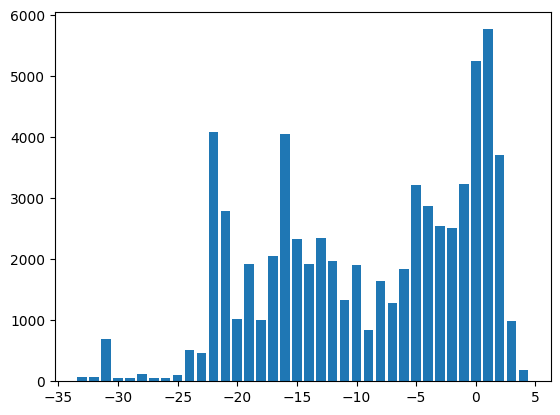

In [34]:
xs, ys = compute_binary_spectrum(binary_image, struct_el)
plt.bar(xs, ys)

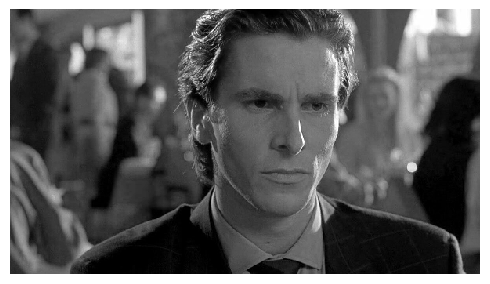

In [35]:
img_gray = imread('Man.png')[::2, ::2, 0]
show_images(img_gray)

In [36]:
def compute_gray_spectrum(image, struct_elem, max_steps=40):
    x_coords = []
    y_values = []
    pad_size = max(struct_elem.shape) // 2
    current_elem = np.array([[1]], dtype=bool)

    for step in range(1, max_steps):
        if not np.any(erosion(image, current_elem)):
            break
        closed_img = closing(image, current_elem)
        current_elem = binary_dilation(pad(current_elem, pad_size, mode="constant"), struct_elem)
        next_closed = closing(image, current_elem)
        diff = next_closed - closed_img
        change_count = np.sum(diff)
        if change_count == 0:
            break
        x_coords.append(-step)
        y_values.append(change_count)

    current_elem = np.array([[1]], dtype=bool)

    for step in range(max_steps):
        opened_img = opening(image, current_elem)
        current_elem = binary_dilation(pad(current_elem, pad_size, mode="constant"), struct_elem)
        next_opened = opening(image, current_elem)
        diff = opened_img - next_opened
        change_count = np.sum(diff)
        if change_count == 0:
            break
        x_coords.append(step)
        y_values.append(change_count)


    return x_coords, y_values

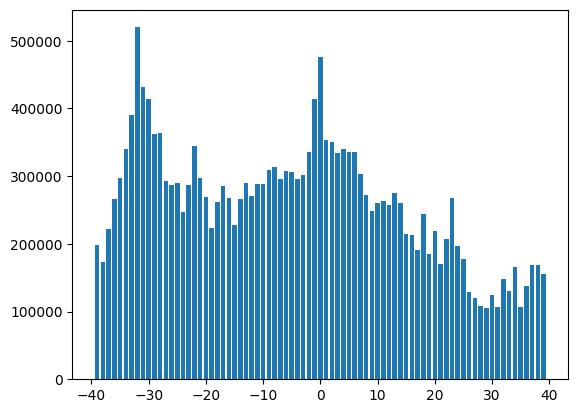

In [37]:
xs, ys = compute_gray_spectrum(img_gray, struct_el)
plt.bar(xs, ys)
plt.show()